Exploratory Data Analysis (EDA)

In [ ]:
from pyspark.sql import SparkSession
import os
import warnings
warnings.simplefilter("ignore", FutureWarning)

os.environ['HADOOP_HOME'] = 'C:\\hadoop'
os.environ['hadoop.home.dir'] = 'C:\\hadoop'

# 1. Initialize Spark Session
spark = SparkSession.builder \
    .appName("Yelp EDA and Queries") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("Spark Session created.")

# 2. Define the path and load the DataFrames
processed_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "processed"))

print("Loading data into memory...")
df_business = spark.read.parquet(os.path.join(processed_dir, "business.parquet"))
df_review = spark.read.orc(os.path.join(processed_dir, "review.orc"))
df_user = spark.read.orc(os.path.join(processed_dir, "user.orc"))
df_checkin = spark.read.parquet(os.path.join(processed_dir, "checkin.parquet"))
df_tip = spark.read.parquet(os.path.join(processed_dir, "tip.parquet"))

print("Success! df_business is now defined.")

Spark Session created.
Loading data into memory...
Success! df_business is now defined.


Descriptive Statistics
This fulfills the requirement to calculate min, max, avg, sum, stddev, variance, skewness, and kurtosis. We will run this on the business stars to see the statistical spread of ratings.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, min, max, avg, sum, stddev, variance, skewness, kurtosis
import pyspark.sql.functions as F

print("Calculating Descriptive Statistics for Business Stars...")

# PySpark aggregation for all required statistical metrics
stats_df = df_business.select(
    min("stars").alias("min_stars"),
    max("stars").alias("max_stars"),
    avg("stars").alias("avg_stars"),
    sum("stars").alias("total_stars_sum"),
    stddev("stars").alias("stddev_stars"),
    variance("stars").alias("variance_stars"),
    skewness("stars").alias("skewness_stars"),
    kurtosis("stars").alias("kurtosis_stars")
)

# Convert to Pandas for a cleaner table display in Jupyter
display(stats_df.toPandas())

Calculating Descriptive Statistics for Business Stars...


,min_stars,max_stars,avg_stars,total_stars_sum,stddev_stars,variance_stars,skewness_stars,kurtosis_stars
0,1.0,5.0,3.596724,540753.0,0.974421,0.949496,-0.537126,-0.397471


Distribution Analysis (Histograms)
This fulfills the requirement for Histograms and Graphical Visualizations. We will count how many businesses have each star rating and plot it.

C:\Users\NICO-DELL\AppData\Local\Temp\ipykernel_43072\1913326232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="stars", y="count", data=stars_dist, palette="viridis")


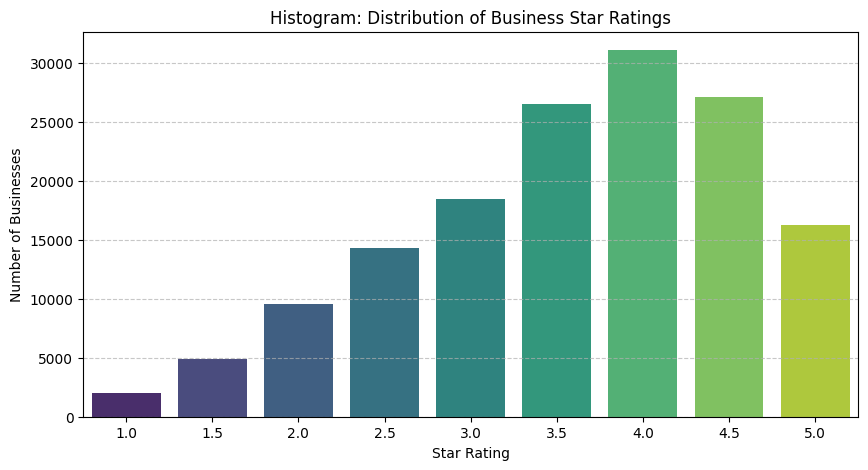

In [3]:
# 1. Aggregate in Spark first (Big Data Best Practice)
stars_dist = df_business.groupBy("stars").count().orderBy("stars").toPandas()

# 2. Plot using Seaborn/Matplotlib
plt.figure(figsize=(10, 5))
sns.barplot(x="stars", y="count", data=stars_dist, palette="viridis")
plt.title("Histogram: Distribution of Business Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Businesses")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Outlier Identification (Boxplots)
This fulfills the Boxplot and Outlier identification requirement. User review counts are famous for having massive outliers (e.g., normal users leave 5 reviews, but "Elite" users leave 5,000).

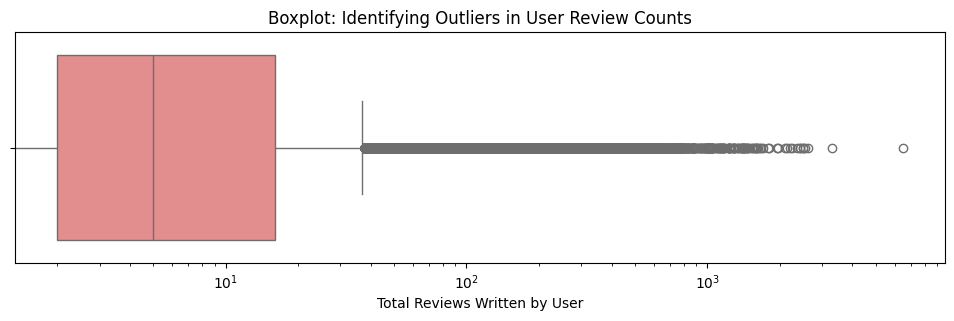

In [4]:
# Extract a 5% random sample of users. 
# (Plotting millions of points in a boxplot crashes the browser; sampling is standard practice).
user_sample = df_user.select("review_count").sample(fraction=0.05, seed=42).toPandas()

plt.figure(figsize=(12, 3))
sns.boxplot(x=user_sample["review_count"], color="lightcoral")
plt.title("Boxplot: Identifying Outliers in User Review Counts")
plt.xlabel("Total Reviews Written by User")
plt.xscale("log") # Using a log scale because the outliers are so extreme
plt.show()

Analysis of Relationships (Correlations & Heatmap)
This fulfills the Correlation Matrix and Heatmap requirement. Let's see if a user's review_count correlates with how many useful, funny, or cool votes they receive.

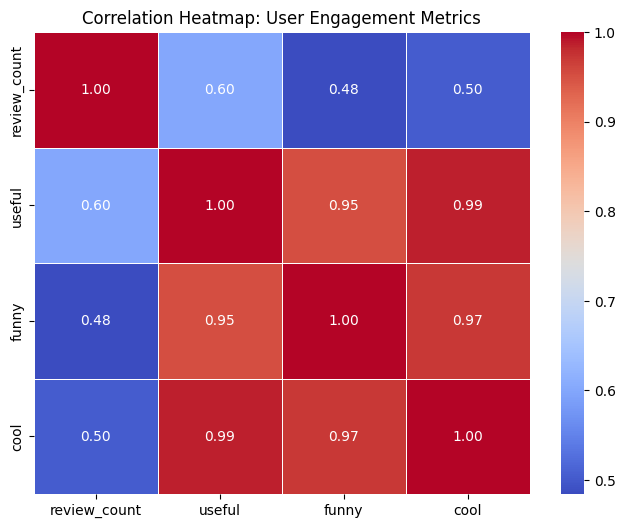

In [5]:
# Select numeric user engagement columns
user_metrics = df_user.select("review_count", "useful", "funny", "cool")

# Calculate the correlation matrix in Pandas (safe since this is an aggregated math operation)
# For massive datasets, we calculate this on a large sample
corr_matrix = user_metrics.sample(fraction=0.1, seed=42).toPandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: User Engagement Metrics")
plt.show()

Category-Based Analysis (Grouping & Aggregations)
This fulfills the "Comparisons between segments" and "Category-based analysis" requirements. We will analyze the average ratings and review counts of the top 10 most common business categories.

Performing Category-Based Analysis...


C:\Users\NICO-DELL\AppData\Local\Temp\ipykernel_43072\923371289.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_businesses", y="category", data=top_categories, palette="magma")


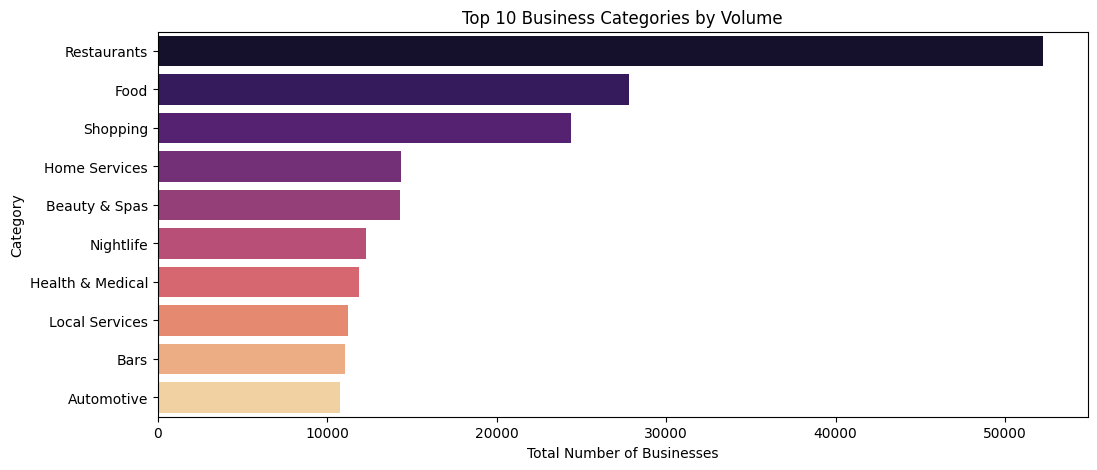

,category,total_businesses,avg_stars,total_reviews
0,Restaurants,52268,3.515172,4561279
1,Food,27781,3.668982,1752281
2,Shopping,24395,3.620988,505372
3,Home Services,14356,3.456778,226962
4,Beauty & Spas,14292,3.810558,354203
5,Nightlife,12281,3.655525,1488163
6,Health & Medical,11890,3.631665,188041
7,Local Services,11198,3.615378,198995
8,Bars,11065,3.648848,1406415
9,Automotive,10773,3.506869,227706


In [6]:
print("Performing Category-Based Analysis...")

# The 'categories' column is a single string like "Restaurants, Burgers, Fast Food".
# We need to split it, explode it into multiple rows, and clean the whitespace.
df_categories = df_business.withColumn("category", F.explode(F.split(F.col("categories"), ","))) \
                           .withColumn("category", F.trim(F.col("category")))

# Group by the individual category to find the most common ones and their stats
category_stats = df_categories.groupBy("category").agg(
    F.count("*").alias("total_businesses"),
    F.avg("stars").alias("avg_stars"),
    F.sum("review_count").alias("total_reviews")
).filter(F.col("category") != "") # Remove empty categories

# Get the top 10 categories by volume and convert to Pandas for visualization
top_categories = category_stats.orderBy(F.col("total_businesses").desc()).limit(10).toPandas()

plt.figure(figsize=(12, 5))
sns.barplot(x="total_businesses", y="category", data=top_categories, palette="magma")
plt.title("Top 10 Business Categories by Volume")
plt.xlabel("Total Number of Businesses")
plt.ylabel("Category")
plt.show()

display(top_categories)

Setup for Spark SQL Queries
To fulfill the specific "Spark Queries" requirement, the cleanest and most impressive way to show your professor you know Big Data is to use actual SQL syntax on your Spark DataFrames. First, we have to register our tables.

In [7]:
# Registering DataFrames as SQL Temporary Views so we can query them directly
df_business.createOrReplaceTempView("business")
df_review.createOrReplaceTempView("review")
df_user.createOrReplaceTempView("user")
df_checkin.createOrReplaceTempView("checkin")
df_tip.createOrReplaceTempView("tip")

print("SQL Temporary Views Registered Successfully. Ready for queries.")

SQL Temporary Views Registered Successfully. Ready for queries.


Implementing 3 Custom Spark Queries (Joins, Filtering, Aggregations)
This single cell executes three complex queries that tick every box in the "Spark Queries" section of your rubric.

In [8]:
print("--- QUERY 1: Aggregation & Filtering ---")
# Find the top 10 cities with the highest average ratings, filtering out small towns (must have > 100 businesses)
query1 = spark.sql("""
    SELECT city, COUNT(*) as business_count, ROUND(AVG(stars), 2) as avg_city_rating
    FROM business
    GROUP BY city
    HAVING business_count > 100
    ORDER BY avg_city_rating DESC
    LIMIT 10
""")
query1.show()


print("--- QUERY 2: Multi-Table Join ---")
# Join Business and Tip tables to find the most recent tips left for elite 5-star businesses
query2 = spark.sql("""
    SELECT b.name, b.city, t.text as recent_tip, t.date
    FROM business b
    JOIN tip t ON b.business_id = t.business_id
    WHERE b.stars = 5.0 AND b.review_count > 500
    ORDER BY t.date DESC
    LIMIT 5
""")
# Setting truncate=False so we can read the full tip text
query2.show(truncate=False)


print("--- QUERY 3: Complex Join & Aggregation ---")
# Join User and Review tables to see if "Power Users" (users with huge amounts of useful votes) give harsher ratings
query3 = spark.sql("""
    SELECT u.name, u.review_count as total_user_reviews, ROUND(AVG(r.stars), 2) as avg_stars_given
    FROM user u
    JOIN review r ON u.user_id = r.user_id
    WHERE u.useful > 5000
    GROUP BY u.name, u.review_count
    ORDER BY total_user_reviews DESC
    LIMIT 10
""")
query3.show()

--- QUERY 1: Aggregation & Filtering ---
+--------------+--------------+---------------+
|          city|business_count|avg_city_rating|
+--------------+--------------+---------------+
| Safety Harbor|           139|           4.13|
| Santa Barbara|          3829|           4.05|
|   Carpinteria|           298|           4.02|
|      Gulfport|           115|            4.0|
|  Lambertville|           124|           3.98|
|     Tampa Bay|           141|           3.94|
|Webster Groves|           111|           3.94|
|  Collingswood|           169|           3.93|
|         Eagle|           289|           3.92|
|       Dunedin|           490|           3.91|
+--------------+--------------+---------------+

--- QUERY 2: Multi-Table Join ---
+----------------------------------+-------------+----------------------------------------------------------------+-------------------+
|name                              |city         |recent_tip                                                      |d